In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_customer = pd.read_csv('C:\\Users\\HP\\OneDrive\\Desktop\\PowerBi\\customer_support_tickets.csv')

In [3]:
df_customer.head(5)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df_customer.shape

(8469, 17)

In [5]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [6]:
# we find out the distribution of Ticket Status
df_customer['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [7]:
df_customer[df_customer['Ticket Status']=='Closed'].shape[0]

2769

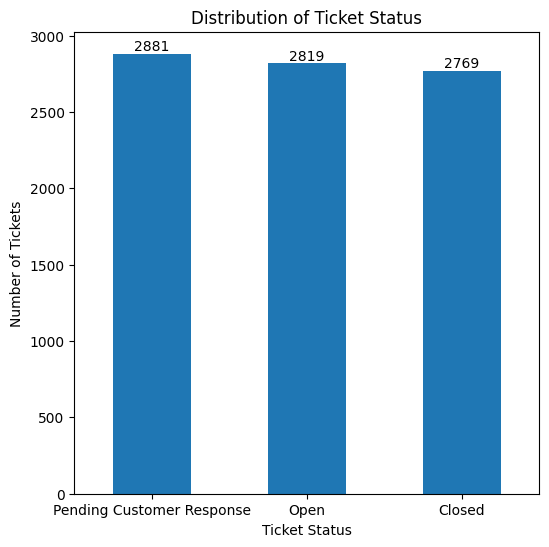

In [8]:
plt.figure(figsize=(6,6))
ax = df_customer['Ticket Status'].value_counts().plot(kind='bar')

ax.bar_label(ax.containers[0])

plt.xlabel('Ticket Status')
plt.ylabel('Number of Tickets')
plt.title('Distribution of Ticket Status')

plt.xticks(rotation=0)
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\PowerBi\bar2.png')

plt.show()

The number of closed Ticket Status is the same as non null Resolution,First Response Time and Customer Satisfaction Rating

In [9]:
#this is to find out whether Ticket Status  and Customer Satisfaction Rating are related in distribution
df_customer.groupby('Ticket Status')['Customer Satisfaction Rating'].count()

Ticket Status
Closed                       2769
Open                            0
Pending Customer Response       0
Name: Customer Satisfaction Rating, dtype: int64

In [10]:
#finding out how many times each customer satisfaction rating appears 
rating_count=df_customer['Customer Satisfaction Rating'].value_counts().sort_index()

In [11]:
rating_count=rating_count.reset_index()

In [12]:
rating_count=rating_count.rename(columns={'count':'Number of Tickets'})

In [13]:
rating_count['Customer Satisfaction Rating']=rating_count['Customer Satisfaction Rating'].astype(int)

In [14]:
rating_count

,Customer Satisfaction Rating,Number of Tickets
0,1,553
1,2,549
2,3,580
3,4,543
4,5,544


In [15]:
rating_count.style

,Customer Satisfaction Rating,Number of Tickets
0,1,553
1,2,549
2,3,580
3,4,543
4,5,544


In [16]:
rating_count.style.hide(axis='index')

Customer Satisfaction Rating,Number of Tickets
1,553
2,549
3,580
4,543
5,544


In [17]:
rating_count['Number of Tickets'].sum()

np.int64(2769)

In [18]:
rating_count['Percentage of Closed Tickets']=((rating_count['Number of Tickets']/rating_count['Number of Tickets'].sum())*100).round(2)

In [19]:
rating_count

,Customer Satisfaction Rating,Number of Tickets,Percentage of Closed Tickets
0,1,553,19.97
1,2,549,19.83
2,3,580,20.95
3,4,543,19.61
4,5,544,19.65


In [20]:
rating_count.style.format({'Percentage of Closed Tickets': '{:.2f}%'})

,Customer Satisfaction Rating,Number of Tickets,Percentage of Closed Tickets
0,1,553,19.97%
1,2,549,19.83%
2,3,580,20.95%
3,4,543,19.61%
4,5,544,19.65%


In [21]:
rating_count.style.format({'Percentage of Closed Tickets': '{:.2f}%'}).hide(axis='index')

Customer Satisfaction Rating,Number of Tickets,Percentage of Closed Tickets
1,553,19.97%
2,549,19.83%
3,580,20.95%
4,543,19.61%
5,544,19.65%


In [22]:
#average customer satisfaction rating for closed tickets status
df_customer.groupby('Ticket Status')['Customer Satisfaction Rating'].mean()


Ticket Status
Closed                       2.991333
Open                              NaN
Pending Customer Response         NaN
Name: Customer Satisfaction Rating, dtype: float64

The average rating for each closed ticket is 2.99

In [23]:
#average customer satisfaction rating for  tickets type
df_customer.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().sort_values(ascending =False)

Ticket Type
Cancellation request    3.029070
Billing inquiry         3.027574
Product inquiry         3.016886
Technical issue         2.958621
Refund request          2.934564
Name: Customer Satisfaction Rating, dtype: float64

In [24]:
#How many customer satisfaction rating for  each  tickets type
df_customer.groupby('Ticket Type')['Customer Satisfaction Rating'].count()

Ticket Type
Billing inquiry         544
Cancellation request    516
Product inquiry         533
Refund request          596
Technical issue         580
Name: Customer Satisfaction Rating, dtype: int64

In [25]:
#Average satisfaction rating for By Ticket Priority
df_customer.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().sort_values(ascending = False)

Ticket Priority
Low         3.052795
High        2.982979
Medium      2.976945
Critical    2.958678
Name: Customer Satisfaction Rating, dtype: float64

In [26]:
#total number of satisfaction rating for By Ticket Priority
df_customer.groupby('Ticket Priority')['Ticket ID'].count().sort_values(ascending = False)

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: Ticket ID, dtype: int64

In [27]:
df_customer_status =df_customer[df_customer['Ticket Status']=='Closed']


In [28]:
df_customer_status.groupby('Ticket Priority')['Customer Satisfaction Rating'].count()

Ticket Priority
Critical    726
High        705
Low         644
Medium      694
Name: Customer Satisfaction Rating, dtype: int64

In [29]:
Ticks_priority=((df_customer_status.groupby('Ticket Priority')['Customer Satisfaction Rating'].count()/df_customer.groupby('Ticket Priority')['Ticket ID'].count())*100).round(2)

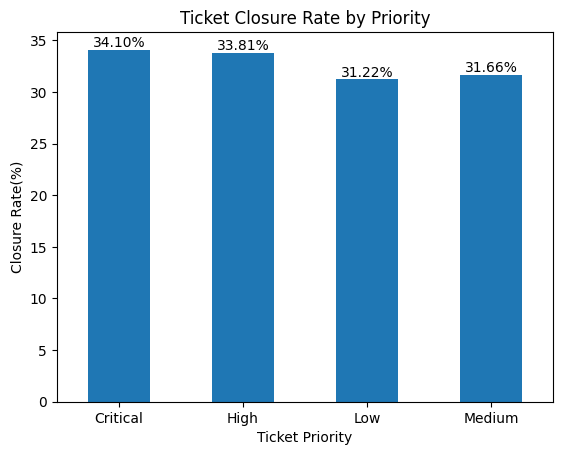

In [30]:
ax=Ticks_priority.plot(kind='bar')
ax.bar_label(ax.containers[0],fmt='%.2f%%')
plt.xlabel('Ticket Priority')
plt.ylabel('Closure Rate(%)')
plt.xticks(rotation =0)
plt.title('Ticket Closure Rate by Priority')
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\fig2.png')
plt.show()

In [31]:
#average Customer Satisfaction Rating for each Ticket Channel
df_customer.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().sort_values(ascending= False)


Ticket Channel
Chat            3.083086
Social media    2.969298
Email           2.963889
Phone           2.952243
Name: Customer Satisfaction Rating, dtype: float64

In [32]:
#the number of non-missing customer satisfaction ratings for each Ticket Channel
df_customer.groupby('Ticket Channel')['Customer Satisfaction Rating'].count().sort_values(ascending =False)


Ticket Channel
Email           720
Phone           691
Social media    684
Chat            674
Name: Customer Satisfaction Rating, dtype: int64

In [33]:
#many tickets are recorded under each Ticket Status for each Ticket Priority.
df_customer.groupby(['Ticket Status','Ticket Priority']).size()

Ticket Status              Ticket Priority
Closed                     Critical           726
                           High               705
                           Low                644
                           Medium             694
Open                       Critical           692
                           High               704
                           Low                696
                           Medium             727
Pending Customer Response  Critical           711
                           High               676
                           Low                723
                           Medium             771
dtype: int64

of all the Ticket priority I found out that Critical had the highest percentage of the ticket that were closed

In [34]:
#creating age_group column
def age_group(Age):
    if Age <=30:
        return '18-30'
    elif Age<=40:
        return '31-40'
    elif Age<=50:
        return '41-50'
    elif Age<=60: 
        return '51-60'
    else:
        return '61-70'
    
        
    

In [35]:
df_customer['Age_group'] =df_customer['Customer Age'].apply(age_group)

In [36]:
df_age2=df_customer.groupby('Age_group')['Ticket ID'].size()

In [37]:
df_age1=df_customer.groupby('Age_group')['Customer Satisfaction Rating'].count()

In [38]:
df_age1/df_age2

Age_group
18-30    0.309900
31-40    0.327060
41-50    0.342965
51-60    0.326567
61-70    0.333758
dtype: float64

The 41–50 age group has the highest percentage of tickets with recorded ratings (34.30%)

In [39]:
df_closed=df_customer[df_customer['Ticket Status']=='Closed']

In [40]:
df_closed.groupby('Age_group')['Ticket Status'].count()

Age_group
18-30    648
31-40    504
41-50    546
51-60    547
61-70    524
Name: Ticket Status, dtype: int64

In [41]:
df_age_group=df_closed.groupby('Age_group')['Customer Satisfaction Rating'].mean()

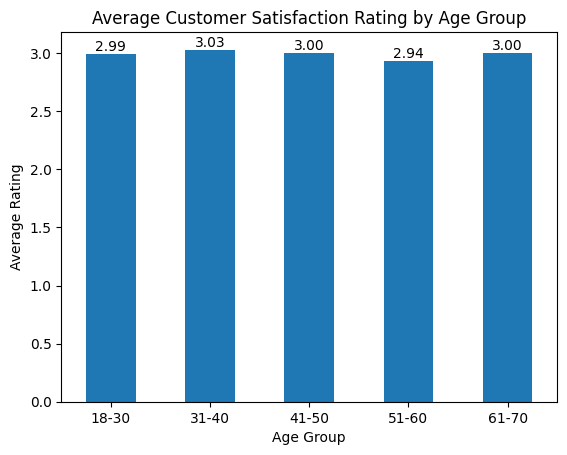

In [42]:
ax=df_age_group.plot(kind='bar')
ax.bar_label(ax.containers[0],fmt='%.2f')
plt.xlabel('Age Group')
plt.ylabel('Average Rating')
plt.title('Average Customer Satisfaction Rating by Age Group')
plt.xticks(rotation =0)
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\PowerBi\fig3.png')
plt.show()

In [43]:
df_customer['Time to Resolution'].dtypes

dtype('O')

In [44]:
df_customer[['First Response Time','Time to Resolution']].head(5)

,First Response Time,Time to Resolution
0,2023-06-01 12:15:36,NaN
1,2023-06-01 16:45:38,NaN
2,2023-06-01 11:14:38,2023-06-01 18:05:38
3,2023-06-01 07:29:40,2023-06-01 01:57:40
4,2023-06-01 00:12:42,2023-06-01 19:53:42


In [45]:
df_customer['Time to Resolution']=pd.to_datetime(df_customer['Time to Resolution'])

In [46]:
df_customer['First Response Time'].dtypes

dtype('O')

In [47]:
df_customer['First Response Time']=pd.to_datetime(df_customer['First Response Time'])

In [48]:
df_customer['Response_to_Resolution']=df_customer['Time to Resolution']-df_customer['First Response Time']

In [49]:
df_customer['Response_to_Resolution'].head(10)

0                 NaT
1                 NaT
2     0 days 06:51:00
3   -1 days +18:28:00
4     0 days 19:41:00
5                 NaT
6                 NaT
7                 NaT
8                 NaT
9                 NaT
Name: Response_to_Resolution, dtype: timedelta64[ns]

In [50]:
negative_count = df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)].shape[0]

In [51]:
non_negative_count = df_customer[
    df_customer['Response_to_Resolution'] >= pd.Timedelta(0)
].shape[0]

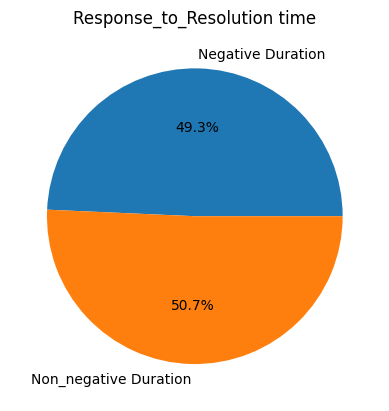

In [52]:
counts=[negative_count,non_negative_count]
labels=['Negative Duration','Non_negative Duration']
plt.pie(counts,labels=labels,autopct='%.1f%%')
plt.title('Response_to_Resolution time')
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\PowerBi\pie1.png')
plt.show()

In [53]:
df_missing = df_customer[df_customer['Response_to_Resolution'].isna()]

In [54]:
df_missing['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

In [55]:
df_customer[df_customer['Response_to_Resolution'].notna()].shape[0]

2769

In [56]:
#find the percentage of the negative resolution time
df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)]['Response_to_Resolution'].shape[0]/df_customer[df_customer['Response_to_Resolution'].notna()].shape[0]


0.49295774647887325

In [57]:
df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)]['Response_to_Resolution'].min()

Timedelta('-1 days +00:46:00')

In [58]:
df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)]['Response_to_Resolution'].max()

Timedelta('-1 days +23:59:00')

In [59]:
df_customer[df_customer['Response_to_Resolution'] >= pd.Timedelta(0)]['Response_to_Resolution'].mean()

Timedelta('0 days 07:34:40.555555555')

Among closed tickets with valid positive timestamp sequences, the average time from first response to recorded resolution was approximately 7 hours 35 minutes; however, this metric should be interpreted cautiously because nearly half of closed tickets contained inconsistent timestamp ordering.

In [60]:
df_customer[df_customer['Response_to_Resolution'] >= pd.Timedelta(0)]['Response_to_Resolution'].median()

Timedelta('0 days 06:20:30')

In [61]:
df_positive=df_customer[df_customer['Response_to_Resolution'] >= pd.Timedelta(0)]

In [62]:
df_positive.groupby('Ticket Priority')['Response_to_Resolution'].median()

Ticket Priority
Critical   0 days 05:59:00
High       0 days 07:07:00
Low        0 days 07:05:00
Medium     0 days 05:52:00
Name: Response_to_Resolution, dtype: timedelta64[ns]

In [63]:
df_positive.groupby('Ticket Priority')['Response_to_Resolution'].count()

Ticket Priority
Critical    374
High        355
Low         334
Medium      341
Name: Response_to_Resolution, dtype: int64

In [64]:
df_negative=df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)]

In [65]:
df_negative.groupby('Ticket Priority')['Response_to_Resolution'].count()

Ticket Priority
Critical    352
High        350
Low         310
Medium      353
Name: Response_to_Resolution, dtype: int64

In [66]:
df_negative[df_negative['Ticket Status']=='Closed'].shape[0]

1365

In [67]:
df_customer[df_customer['Ticket Status']=='Closed'].shape[0]

2769

In [68]:
df_customer[df_customer['Response_to_Resolution'] < pd.Timedelta(0)]['Response_to_Resolution'].shape[0]/df_customer[df_customer['Ticket Status']=='Closed'].shape[0]

0.49295774647887325

In [69]:
df_customer[(df_customer['Ticket Priority']=='Critical') &(df_customer['Ticket Status']=='Closed')].shape[0]

726

In [70]:
df_negative[df_negative['Ticket Priority']=='Critical'].shape[0]

352

In [71]:
df_negative.groupby('Ticket Priority')['Response_to_Resolution'].count()

Ticket Priority
Critical    352
High        350
Low         310
Medium      353
Name: Response_to_Resolution, dtype: int64

In [72]:
df_customer.groupby('Ticket Priority')['Response_to_Resolution'].count()

Ticket Priority
Critical    726
High        705
Low         644
Medium      694
Name: Response_to_Resolution, dtype: int64

In [73]:
#the percentage ticket Priority that has negative resolution time
((df_negative.groupby('Ticket Priority')['Response_to_Resolution'].
 count()/df_customer.groupby('Ticket Priority')['Response_to_Resolution'].count())*100).round(2)

Ticket Priority
Critical    48.48
High        49.65
Low         48.14
Medium      50.86
Name: Response_to_Resolution, dtype: float64

In [74]:
#Percentage of Closed tickets with negative response-to-resolution time by Ticket Type
((df_negative.groupby('Ticket Type')['Response_to_Resolution'].
 count()/df_customer.groupby('Ticket Type')['Response_to_Resolution'].count())*100).round(2)

Ticket Type
Billing inquiry         49.82
Cancellation request    48.64
Product inquiry         51.78
Refund request          48.99
Technical issue         47.41
Name: Response_to_Resolution, dtype: float64

In [75]:
((df_negative.groupby('Ticket Channel')['Response_to_Resolution'].
 count()/df_customer.groupby('Ticket Channel')['Response_to_Resolution'].count())*100).round(2)

Ticket Channel
Chat            47.33
Email           48.06
Phone           52.68
Social media    49.12
Name: Response_to_Resolution, dtype: float64

49.3% of Closed tickets have inconsistent timestamp ordering, and the issue appears broadly across priorities, ticket types, and channels. Therefore, any response-to-resolution KPI should be calculated only on valid non-negative records and clearly labeled with this limitation.

In [76]:
df_positive.groupby('Ticket Channel')['Response_to_Resolution'].median()

Ticket Channel
Chat           0 days 06:31:00
Email          0 days 06:24:30
Phone          0 days 06:03:00
Social media   0 days 06:25:30
Name: Response_to_Resolution, dtype: timedelta64[ns]

In [77]:
df_positive.groupby('Ticket Type')['Response_to_Resolution'].median()

Ticket Type
Billing inquiry        0 days 05:16:00
Cancellation request   0 days 06:22:00
Product inquiry        0 days 06:59:00
Refund request         0 days 06:42:30
Technical issue        0 days 06:23:00
Name: Response_to_Resolution, dtype: timedelta64[ns]

In [78]:
df_positive.groupby('Ticket Type')['Response_to_Resolution'].count()

Ticket Type
Billing inquiry         273
Cancellation request    265
Product inquiry         257
Refund request          304
Technical issue         305
Name: Response_to_Resolution, dtype: int64

In [79]:
df_customer.groupby('Ticket Type')['Customer Satisfaction Rating'].mean()

Ticket Type
Billing inquiry         3.027574
Cancellation request    3.029070
Product inquiry         3.016886
Refund request          2.934564
Technical issue         2.958621
Name: Customer Satisfaction Rating, dtype: float64